In [ ]:
!pip install evaluate seqeval

In [ ]:
import pandas as pd
import re
import os
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.util import ngrams
import math
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import FreqDist, ConditionalFreqDist
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch import nn
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from typing import List, Tuple
from transformers import MarianMTModel, MarianTokenizer, DistilBertTokenizerFast, TrainingArguments, Trainer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForTokenClassification, DataCollatorForTokenClassification
from tqdm import tqdm
import evaluate
from google.colab import drive
drive.mount('/content/drive')

splits = {'train': 'train.parquet', 'validation': 'validation.parquet'}
df_train = pd.read_parquet("hf://datasets/coastalcph/tydi_xor_rc/" + splits["train"])
df_val = pd.read_parquet("hf://datasets/coastalcph/tydi_xor_rc/" + splits["validation"])

df_train = df_train[df_train['lang'].isin(['ar', 'te', 'ko'])]
df_val = df_val[df_val['lang'].isin(['ar', 'te', 'ko'])]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
[(row['context'][row['answer_start']:row['answer_start']+len(row['answer'])],
  row['answer']) for _, row in df_train.iterrows()]

[('France', 'France'),
 ('Wilhelm Röntgen', 'Wilhelm Röntgen'),
 ('2004', '2004'),
 ('British Broadcasting Corporation (BBC)',
  'British Broadcasting Corporation (BBC)'),
 ('Jerusalem', 'Jerusalem'),
 ('Andromeda', 'Andromeda'),
 ('Smith–Putnam wind turbine', 'Smith–Putnam wind turbine'),
 ('Louis, Dauphin', 'Louis, Dauphin'),
 ('CBS', 'CBS'),
 ('Chandragupta Maurya', 'Chandragupta Maurya'),
 ('appointed "Reichsführer-SS" by Hitler',
  'appointed "Reichsführer-SS" by Hitler'),
 ('Silicon', 'Silicon'),
 ('1945', '1945'),
 ('Subway', 'Subway'),
 ('22 November 2005', '22 November 2005'),
 ('London', 'London'),
 ('USSR', 'USSR'),
 ('', 'no'),
 ('one-quarter', 'one-quarter'),
 ('Vertigo', 'Vertigo'),
 ('7th place', '7th place'),
 ('Charles Darwin', 'Charles Darwin'),
 ('Islamic State', 'Islamic State'),
 ('Revelation', 'Revelation'),
 ('UuU', 'UuU'),
 ('Sydney', 'Sydney'),
 ('"MUD1"', '"MUD1"'),
 ('2,932, excluding military personnel serving in the archipelago and their dependents. A 2012 

In [ ]:
modelName = "distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(modelName)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [ ]:
def create_bio_tags_and_indices(context, answer_start, answer, tokenizer):

    encoded = tokenizer(
        context,
        return_offsets_mapping = True,
        add_special_tokens = False)

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    offsets = encoded["offset_mapping"]

    tags = ["O"] * len(tokens)

    if not pd.isna(answer_start) and not pd.isna(answer):
        answer_end = answer_start + len(answer)
        inside_answer  = False
        for i, (start, end) in enumerate(offsets):

            if end <= answer_start or start >= answer_end:
                continue
            if not inside_answer:
                tags[i] = "B-ANS"
                inside_answer = True
            else:
                tags[i] = "I-ANS"
    else:
        inside_answer = False

    token_data = [
        {"word": tok, "start": s, "end": e, "tag": tag}
        for tok, (s, e), tag in zip(tokens, offsets, tags)]

    return token_data

In [ ]:

tag2id = {"O": 0, "ANS": 1}
id2tag = {v: k for k, v in tag2id.items()}

def encode_example(example, tokenizer, tag2id=tag2id, max_length=512):
    encoding = tokenizer(
        example["question"], example["context"],
        truncation="only_second",
        max_length=max_length,
        padding="max_length",
        return_offsets_mapping=True)

    sequence_ids = encoding.sequence_ids()
    labels = []

    if example["answer_start"] == -1:
        for seq_id in sequence_ids:
            if seq_id != 1:
                labels.append(-100)
            else:
                labels.append(tag2id["O"])
    else:
        start = example["answer_start"]
        end = start + len(example["answer"])

        for idx, seq_id in enumerate(sequence_ids):
            if seq_id != 1:
                labels.append(-100)
                continue

            token_start, token_end = encoding["offset_mapping"][idx]
            if token_end <= start or token_start >= end:
                labels.append(tag2id["O"])
            else:
                labels.append(tag2id["ANS"])

    encoding["labels"] = labels
    encoding.pop("offset_mapping")
    return encoding

In [ ]:
index = 109

example_row = {
    "question": df_val.iloc[index]['question'],
    "context": df_val.iloc[index]['context'],
    "answer_start": df_val.iloc[index]['answer_start'],
    "answer": df_val.iloc[index]['answer']
}

encoded_example = encode_example(example_row, tokenizer)

tokens = tokenizer.convert_ids_to_tokens(encoded_example["input_ids"])
labels = encoded_example["labels"]

for tok, lab in zip(tokens, labels):
    label_str = id2tag[lab] if lab != -100 else "PAD/IGN"
    print(f"{tok:15} -> {label_str}")

[CLS]           -> PAD/IGN
2011            -> PAD/IGN
##లో            -> PAD/IGN
అ               -> PAD/IGN
##మ             -> PAD/IGN
##ె             -> PAD/IGN
##రికా          -> PAD/IGN
అ               -> PAD/IGN
##ధ             -> PAD/IGN
##్య            -> PAD/IGN
##క్ష           -> PAD/IGN
##ు             -> PAD/IGN
##డి            -> PAD/IGN
##గా            -> PAD/IGN
ఎ               -> PAD/IGN
##వ             -> PAD/IGN
##రు            -> PAD/IGN
ప               -> PAD/IGN
##ని            -> PAD/IGN
##చే            -> PAD/IGN
##స             -> PAD/IGN
##ారు           -> PAD/IGN
?               -> PAD/IGN
[SEP]           -> PAD/IGN
The             -> O
presidency      -> O
of              -> O
Barack          -> ANS
Obama           -> ANS
began           -> O
at              -> O
no              -> O
##on            -> O
ES              -> O
##T             -> O
on              -> O
January         -> O
20              -> O
,               -> O
2009            -> O
,           

In [ ]:
context = df_train.iloc[index]['context']
answer_start = df_train.iloc[index]['answer_start']
answer = df_train.iloc[index]['answer']

tagged_tokens = create_bio_tags_and_indices(context, answer_start, answer, tokenizer)

for token in tagged_tokens:
    print(f"{token['word']:15} -> {token['tag']:>2} -> ({token['start']},{token['end']})")

When            -> B-ANS -> (0,4)
on              ->  O -> (5,7)
land            ->  O -> (8,12)
,               ->  O -> (12,13)
an              ->  O -> (14,16)
American        ->  O -> (17,25)
all             ->  O -> (26,29)
##iga           ->  O -> (29,32)
##tor           ->  O -> (32,35)
moves           ->  O -> (36,41)
either          ->  O -> (42,48)
by              ->  O -> (49,51)
spraw           ->  O -> (52,57)
##ling          ->  O -> (57,61)
or              ->  O -> (62,64)
walking         ->  O -> (65,72)
,               ->  O -> (72,73)
the             ->  O -> (74,77)
latter          ->  O -> (78,84)
involving       ->  O -> (85,94)
the             ->  O -> (95,98)
rep             ->  O -> (99,102)
##tile          ->  O -> (102,106)
lift            ->  O -> (107,111)
##ing           ->  O -> (111,114)
its             ->  O -> (115,118)
bell            ->  O -> (119,123)
##y             ->  O -> (123,124)
off             ->  O -> (125,128)
the             ->  O -> (129,

In [ ]:
def tokenize_dataset(df, tokenizer):
    encoded_list = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        example = {
            "question": row["question"],
            "context": row["context"],
            "answer_start": row["answer_start"],
            "answer": row["answer"]
        }
        encoded = encode_example(example, tokenizer)
        encoded_list.append(encoded)
    return encoded_list

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

save_path = "/content/drive/MyDrive/translated_data/week40_bert"
if os.path.exists(save_path) and any(os.scandir(save_path)):
    print(f"Model initialized from: {save_path}")
    model = AutoModelForTokenClassification.from_pretrained(save_path)
    tokenizer = AutoTokenizer.from_pretrained(save_path)
    train_model = False
else:
    print("Creating model:")
    model = AutoModelForTokenClassification.from_pretrained(
        modelName,
        num_labels=2,
        id2label={0: "O", 1: "ANS"},
        label2id={"O": 0, "ANS": 1},
        train_model = True)

model.to(device)

training_args = TrainingArguments(
    output_dir=".bioqa-model1",
    eval_strategy = "epoch",
    learning_rate = 5e-5,
    per_device_train_batch_size = 32,
    num_train_epochs = 10,
    weight_decay = 0.01,
    save_total_limit = 2,
    logging_dir="./logs",
    logging_steps = 50,
    report_to = "none")

Using device: cuda
Model initialized from: /content/drive/MyDrive/translated_data/week40_bert


In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer)

seqeval_metric = evaluate.load("seqeval")

def compute_qa_metrics(p):
    predictions, labels = p
    predictions = predictions.argmax(-1)


    true_predictions = [
        [id2tag[pred] for pred, lab in zip(prediction, label) if lab != -100]
        for prediction, label in zip(predictions, labels)]
    true_labels = [
        [id2tag[lab] for pred, lab in zip(prediction, label) if lab != -100]
        for prediction, label in zip(predictions, labels)]

    seqeval_results = seqeval_metric.compute(predictions=true_predictions, references=true_labels)

    def bio_to_spans(tags):
        spans = []
        start = None
        for i, tag in enumerate(tags):
            if tag.startswith("B"):
                if start is not None:
                    spans.append((start, i-1))
                start = i
            elif tag == "O":
                if start is not None:
                    spans.append((start, i-1))
                    start = None
        if start is not None:
            spans.append((start, len(tags)-1))
        return spans

    exact_matches = []
    f1_scores = []

    for pred_tags, true_tags in zip(true_predictions, true_labels):
        pred_spans = bio_to_spans(pred_tags)
        true_spans = bio_to_spans(true_tags)

        exact_matches.append(int(pred_spans == true_spans))

        pred_tokens = set()
        for start, end in pred_spans:
            pred_tokens.update(range(start, end+1))
        true_tokens = set()
        for start, end in true_spans:
            true_tokens.update(range(start, end+1))

        tp = len(pred_tokens & true_tokens)
        fp = len(pred_tokens - true_tokens)
        fn = len(true_tokens - pred_tokens)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1_scores.append(f1)

    start_correct = 0
    end_correct = 0
    total = len(true_predictions)
    for pred_tags, true_tags in zip(true_predictions, true_labels):
        pred_spans = bio_to_spans(pred_tags)
        true_spans = bio_to_spans(true_tags)
        if pred_spans and true_spans:
            start_correct += int(pred_spans[0][0] == true_spans[0][0])
            end_correct += int(pred_spans[-1][1] == true_spans[-1][1])
        else:
            start_correct += int(pred_spans == true_spans)
            end_correct += int(pred_spans == true_spans)

    metrics = {
        "token_precision": seqeval_results["overall_precision"],
        "token_recall": seqeval_results["overall_recall"],
        "token_f1": seqeval_results["overall_f1"],
        "token_accuracy": seqeval_results["overall_accuracy"],
        "span_exact_match": np.mean(exact_matches),
        "span_f1": np.mean(f1_scores),
        "start_accuracy": start_correct / total,
        "end_accuracy": end_correct / total}

    return metrics

In [ ]:
class_weights = torch.tensor([1, 2.5]).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

class WeightedTokenClassificationModel(nn.Module):
    def __init__(self, model, class_weights):
        super().__init__()
        self.model = model
        self.class_weights = class_weights
        self.loss_fn = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = None
        if labels is not None:
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        return {'loss': loss, 'logits': logits}

weighted_model = WeightedTokenClassificationModel(model, class_weights)

In [ ]:
encoded_train = tokenize_dataset(df_train, tokenizer)
encoded_val = tokenize_dataset(df_val, tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train,
    eval_dataset=encoded_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_qa_metrics)

100%|██████████| 1155/1155 [00:03<00:00, 340.88it/s]
/tmp/ipython-input-595913030.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
if train_model:
    trainer.train()
    results = trainer.evaluate()
    print(results)
else:
    print("Skipping training, pretrained model is already loaded.")

Skipping training, pretrained model is already loaded.


In [ ]:
save_path = "/content/drive/MyDrive/translated_data/week40_bert"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved at: {save_path}")

Model saved at: /content/drive/MyDrive/translated_data/week40_bert


In [ ]:
test_path = "/content/drive/MyDrive/translated_data/test.json"

test_df = pd.read_json(test_path)
encoded_test = tokenize_dataset(test_df, tokenizer)

eval_trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=encoded_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_qa_metrics)

results = eval_trainer.evaluate()
print(results)

100%|██████████| 20/20 [00:00<00:00, 329.43it/s]
/tmp/ipython-input-3418724687.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  eval_trainer = Trainer(


{'eval_loss': 0.2035808265209198, 'eval_model_preparation_time': 0.0041, 'eval_token_precision': 0.0, 'eval_token_recall': 0.0, 'eval_token_f1': 0.0, 'eval_token_accuracy': 0.9622754491017964, 'eval_span_exact_match': 1.0, 'eval_span_f1': 0.0, 'eval_start_accuracy': 1.0, 'eval_end_accuracy': 1.0, 'eval_runtime': 1.4005, 'eval_samples_per_second': 14.281, 'eval_steps_per_second': 2.142}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ANS seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


In [ ]:
preds_output = eval_trainer.predict(encoded_test)
predictions = preds_output.predictions.argmax(-1)
labels = preds_output.label_ids

true_predictions = [
    [id2tag[pred] for pred, lab in zip(prediction, label) if lab != -100]
    for prediction, label in zip(predictions, labels)]
true_labels = [
    [id2tag[lab] for pred, lab in zip(prediction, label) if lab != -100]
    for prediction, label in zip(predictions, labels)]

for i in range(10):
    print(f"Example {i}")
    print("Context:", test_df.iloc[i]["context"])
    print("Question:", test_df.iloc[i]["question"])
    print("Ground truth tags:", true_labels[i])
    print("Predicted tags:", true_predictions[i])
    print()


Example 0
Context: The Eiffel Tower is a wrought-iron lattice tower located on the Champ de Mars in Paris, France. It was constructed between 1887 and 1889 for the 1889 Exposition Universelle (World's Fair) to celebrate the 100th anniversary of the French Revolution. The tower was initially criticized by many leading artists and intellectuals in France, who called it an eyesore, but it has since become one of the most recognized structures in the world. It was designed by Gustave Eiffel and built by his engineering company, showcasing both innovative design and engineering prowess.
Question: Hvem designede Eiffeltårnet?
Ground truth tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O

In [ ]:
seqeval_metric = evaluate.load("seqeval")

def evaluate_prf_per_language(df_val, tokenizer, model, id2tag, device):

    languages = df_val['lang'].unique()
    results = {}

    def encode_rows(df):
        return [encode_example(row, tokenizer) for _, row in df.iterrows()]

    def predict(encodings):
        preds = []
        model.eval()
        for enc in encodings:
            input_ids = torch.tensor([enc["input_ids"]]).to(device)
            attention_mask = torch.tensor([enc["attention_mask"]]).to(device)
            with torch.no_grad():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                pred_ids = torch.argmax(logits, dim=-1).squeeze().cpu().numpy()
                preds.append(pred_ids)
        return preds

    def convert_preds_to_tags(predictions, encodings):
        pred_tags = []
        for pred, enc in zip(predictions, encodings):
            tags = []
            for p, l in zip(pred, enc["labels"]):
                if l == -100:
                    tags.append("IGN")
                else:
                    tags.append(id2tag[p])
            pred_tags.append(tags)
        return pred_tags

    def bio_to_spans(tags):
        spans = []
        start = None
        for i, tag in enumerate(tags):
            if tag != "O" and tag != "IGN":
                if start is None:
                    start = i
            else:
                if start is not None:
                    spans.append((start, i-1))
                    start = None
        if start is not None:
            spans.append((start, len(tags)-1))
        return spans

    for lang in languages:
        df_lang = df_val[df_val['lang'] == lang]
        encodings = encode_rows(df_lang)
        predictions = predict(encodings)
        pred_tags = convert_preds_to_tags(predictions, encodings)

        true_labels = [
            [id2tag[l] for l in enc["labels"] if l != -100]
            for enc in encodings]
        filtered_preds = [
            [t for t, l in zip(pred, enc["labels"]) if l != -100]
            for pred, enc in zip(pred_tags, encodings)]
        token_results = seqeval_metric.compute(predictions=filtered_preds, references=true_labels)
        token_precision = token_results["overall_precision"]
        token_recall = token_results["overall_recall"]
        token_f1 = token_results["overall_f1"]

        span_precisions = []
        span_recalls = []
        span_f1s = []
        for pred_tags_i, true_tags_i in zip(filtered_preds, true_labels):
            pred_spans = bio_to_spans(pred_tags_i)
            true_spans = bio_to_spans(true_tags_i)

            pred_tokens = set()
            for s, e in pred_spans:
                pred_tokens.update(range(s, e+1))
            true_tokens = set()
            for s, e in true_spans:
                true_tokens.update(range(s, e+1))

            tp = len(pred_tokens & true_tokens)
            fp = len(pred_tokens - true_tokens)
            fn = len(true_tokens - pred_tokens)

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

            span_precisions.append(precision)
            span_recalls.append(recall)
            span_f1s.append(f1)

        results[lang] = {
            "token_precision": token_precision,
            "token_recall": token_recall,
            "token_f1": token_f1,
            "span_precision": np.mean(span_precisions),
            "span_recall": np.mean(span_recalls),
            "span_f1": np.mean(span_f1s)}

    return results

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
results = evaluate_prf_per_language(df_val, tokenizer, model, id2tag, device)

for lang, scores in results.items():
    print(f"{lang}:")
    print(f"  Token-level  -> Precision: {scores['token_precision']:.3f}, Recall: {scores['token_recall']:.3f}, F1: {scores['token_f1']:.3f}")
    print(f"  Span-level   -> Precision: {scores['span_precision']:.3f}, Recall: {scores['span_recall']:.3f}, F1: {scores['span_f1']:.3f}")

te:
  Token-level  -> Precision: 0.265, Recall: 0.278, F1: 0.271
  Span-level   -> Precision: 0.283, Recall: 0.283, F1: 0.256
ko:
  Token-level  -> Precision: 0.362, Recall: 0.329, F1: 0.345
  Span-level   -> Precision: 0.418, Recall: 0.413, F1: 0.393
ar:
  Token-level  -> Precision: 0.388, Recall: 0.369, F1: 0.379
  Span-level   -> Precision: 0.392, Recall: 0.416, F1: 0.388


In [ ]:
def debug_tokenization(context, answer_start, answer, tokenizer, label2id):
    tokens = context.split()
    tags = ["O"] * len(tokens)

    answer_tokens = answer.split()
    for i, token in enumerate(tokens):
        if " ".join(tokens[i:i+len(answer_tokens)]) == answer:
            tags[i] = "B-ANS"
            for j in range(1, len(answer_tokens)):
                tags[i+j] = "I-ANS"
            break

    encoding = tokenizer(tokens, is_split_into_words=True, return_offsets_mapping=True, truncation=True, padding="longest")

    word_ids = encoding.word_ids()
    labels = []
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        else:
            labels.append(label2id[tags[word_idx]])

    print(f"{'Token':20} {'WordID':6} {'LabelID':7} Label")
    print("-" * 50)
    for token, w_id, l_id in zip(tokenizer.convert_ids_to_tokens(encoding['input_ids']), word_ids, labels):
        label = [k for k,v in label2id.items() if v == l_id][0] if l_id != -100 else "IGN"
        print(f"{token:20} {str(w_id):6} {str(l_id):7} {label}")

In [ ]:
all_labels = []
for ex in encoded_train:
    all_labels.extend([l for l in ex["labels"] if l != -100])

Counter(all_labels)

Counter({0: 823704, 1: 28845})

In [ ]:
index = 1
example_row = {
    "question": df_train.iloc[index]["question"],
    "context": df_train.iloc[index]["context"],
    "answer_start": df_train.iloc[index]["answer_start"],
    "answer": df_train.iloc[index]["answer"]}

encoded_ex = encode_example(example_row, tokenizer)
tokens = tokenizer.convert_ids_to_tokens(encoded_ex["input_ids"])

for t, sid, l in zip(tokens, encoded_ex.sequence_ids(), encoded_ex["labels"]):
    print(f"{t:<15}  seq={sid}  {id2tag.get(l, 'IGN')}")


[CLS]            seq=None  IGN
엑                seq=0  IGN
##스              seq=0  IGN
##선              seq=0  IGN
##은              seq=0  IGN
누                seq=0  IGN
##가              seq=0  IGN
발                seq=0  IGN
##견              seq=0  IGN
##하              seq=0  IGN
##였              seq=0  IGN
##는              seq=0  IGN
##가              seq=0  IGN
?                seq=0  IGN
[SEP]            seq=None  IGN
X                seq=1  O
-                seq=1  O
ray              seq=1  O
##s              seq=1  O
make             seq=1  O
up               seq=1  O
X                seq=1  O
-                seq=1  O
radiation        seq=1  O
,                seq=1  O
a                seq=1  O
form             seq=1  O
of               seq=1  O
elect            seq=1  O
##roma           seq=1  O
##gnet           seq=1  O
##ic             seq=1  O
radiation        seq=1  O
.                seq=1  O
Most             seq=1  O
X                seq=1  O
-                seq=1  O
ra

Token indices sequence length is longer than the specified maximum sequence length for this model (562 > 512). Running this sequence through the model will result in indexing errors


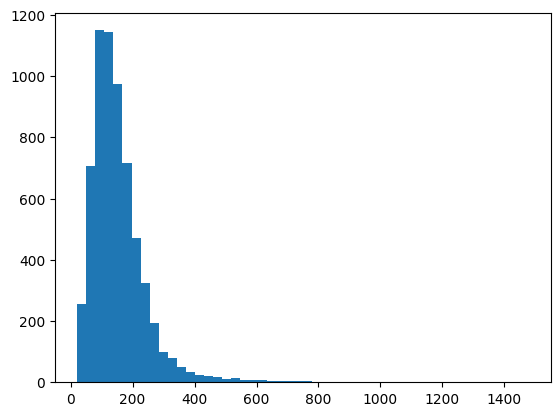

In [ ]:
lengths = [len(tokenizer(q, c)["input_ids"]) for q, c in zip(df_train["question"], df_train["context"])]
import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.show()

In [ ]:
sample_val = df_val.sample(5, random_state=42)
encoded_sample = [encode_example(row, tokenizer) for _, row in sample_val.iterrows()]

model.eval()
predictions = []

for enc in encoded_sample:
    input_ids = torch.tensor([enc["input_ids"]]).to(device)
    attention_mask = torch.tensor([enc["attention_mask"]]).to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        pred_ids = torch.argmax(logits, dim=-1).squeeze().cpu().numpy()
        predictions.append(pred_ids)

pred_tags = []
for pred, enc in zip(predictions, encoded_sample):
    tags = []
    for id, label in zip(pred, enc["labels"]):
        if label == -100:
            tags.append("IGN")
        else:
            tags.append(id2tag[id])
    pred_tags.append(tags)

for i, enc in enumerate(encoded_sample):
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print(f"\nExample {i+1}: {sample_val.iloc[i]['question']}")
    for t, pred_tag, true_id in zip(tokens, pred_tags[i], enc["labels"]):
        true_tag = id2tag.get(true_id, "IGN") if true_id != -100 else "IGN"
        print(f"{t:15} Pred: {pred_tag:5} True: {true_tag}")

def tokens_to_text(tokens, tags):
    answer = ""
    inside = False
    for tok, tag in zip(tokens, tags):
        if tag == "B-ANS":
            if inside:
                answer += " "
            answer += tok.replace("##", "")
            inside = True
        elif tag == "I-ANS" and inside:
            answer += tok.replace("##", "")
        else:
            inside = False
    return answer

print(sample_val.index.tolist())

for i, enc in enumerate(encoded_sample):
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    pred_answer = tokens_to_text(tokens, pred_tags[i])
    true_answer = sample_val.iloc[i]["answer"]
    question = sample_val.iloc[i]["question"]
    print(f"\nQuestion: {question}")
    print(f"Predicted answer: {pred_answer}")
    print(f"Ground truth:    {true_answer}")

for enc in encoded_sample:
    print(enc["labels"])


Example 1: ما معنى كلمة الهاجاناه بالعبرية؟
[CLS]           Pred: IGN   True: IGN
ما              Pred: IGN   True: IGN
مع              Pred: IGN   True: IGN
##نى            Pred: IGN   True: IGN
كلمة            Pred: IGN   True: IGN
ال              Pred: IGN   True: IGN
##ها            Pred: IGN   True: IGN
##جان           Pred: IGN   True: IGN
##اه            Pred: IGN   True: IGN
با              Pred: IGN   True: IGN
##ل             Pred: IGN   True: IGN
##عب            Pred: IGN   True: IGN
##رية           Pred: IGN   True: IGN
؟               Pred: IGN   True: IGN
[SEP]           Pred: IGN   True: IGN
Ha              Pred: O     True: O
##gana          Pred: O     True: O
##h             Pred: O     True: O
(               Pred: O     True: O
,               Pred: O     True: O
lit             Pred: O     True: O
.               Pred: O     True: O
"               Pred: O     True: O
The             Pred: O     True: ANS
Defence         Pred: O     True: ANS
"               Pred:

In [ ]:
all_labels = np.concatenate([enc["labels"] for enc in encoded_sample])
unique, counts = np.unique(all_labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-100): np.int64(1855), np.int64(0): np.int64(698), np.int64(1): np.int64(7)}


## Second model (RoBERTa)

In [ ]:
modelName_xlm = "xlm-roberta-base"

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

xlm_path = "/content/drive/MyDrive/translated_data/week40_roberta"

if os.path.exists(xlm_path) and any(os.scandir(xlm_path)):
    print(f"Model initialized from: {xlm_path}")
    model_xlm = AutoModelForTokenClassification.from_pretrained(xlm_path)
    tokenizer_xlm = AutoTokenizer.from_pretrained(xlm_path)
    train_xlm = False
else:
    print("Creating xlm model:")
    tokenizer_xlm = AutoTokenizer.from_pretrained(modelName_xlm)
    model_xlm = AutoModelForTokenClassification.from_pretrained(
        modelName_xlm,
        num_labels= 2,
        id2label={0: "O", 1: "ANS"},
        label2id={"O": 0, "ANS": 1})
    train_xlm = True

model_xlm.to(device)

training_args_xlm = TrainingArguments(
    output_dir=".xlm_roberta",
    eval_strategy = "epoch",
    learning_rate = 5e-5,
    per_device_train_batch_size = 32,
    num_train_epochs = 5,
    weight_decay = 0.01,
    save_total_limit = 2,
    logging_dir="./logs",
    logging_steps = 50,
    report_to = "none")

Using device: cuda
Model initialized from: /content/drive/MyDrive/translated_data/week40_roberta


In [ ]:
encoded_train_xlm = tokenize_dataset(df_train, tokenizer_xlm)
encoded_val_xlm = tokenize_dataset(df_val, tokenizer_xlm)

trainer_xlm = Trainer(
    model=model_xlm,
    args=training_args_xlm,
    train_dataset=encoded_train_xlm,
    eval_dataset=encoded_val_xlm,
    tokenizer=tokenizer_xlm,
    data_collator=data_collator,
    compute_metrics=compute_qa_metrics)

100%|██████████| 1155/1155 [00:01<00:00, 688.77it/s]
/tmp/ipython-input-606870921.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_xlm = Trainer(


In [ ]:
if train_xlm:
    trainer_xlm.train()
    results_xlm = trainer_xlm.evaluate()
    print(results_xlm)
else:
    print("Model already initialized, skipping training.")

trainer_xlm.save_model(xlm_path)
tokenizer_xlm.save_pretrained(xlm_path)

print(f"XLM model saved in: {xlm_path}")

Model already initialized, skipping training.
XLM model saved in: /content/drive/MyDrive/translated_data/week40_roberta


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
results_xlm = evaluate_prf_per_language(df_val, tokenizer_xlm, model_xlm, id2tag, device)

for lang, scores in results_xlm.items():
    print(f"{lang}:")
    print(f"  Token-level  -> Precision: {scores['token_precision']:.3f}, Recall: {scores['token_recall']:.3f}, F1: {scores['token_f1']:.3f}")
    print(f"  Span-level   -> Precision: {scores['span_precision']:.3f}, Recall: {scores['span_recall']:.3f}, F1: {scores['span_f1']:.3f}")

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ANS seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


te:
  Token-level  -> Precision: 0.312, Recall: 0.416, F1: 0.356
  Span-level   -> Precision: 0.417, Recall: 0.422, F1: 0.389
ko:
  Token-level  -> Precision: 0.434, Recall: 0.475, F1: 0.453
  Span-level   -> Precision: 0.552, Recall: 0.586, F1: 0.549
ar:
  Token-level  -> Precision: 0.381, Recall: 0.457, F1: 0.416
  Span-level   -> Precision: 0.503, Recall: 0.552, F1: 0.502


In [ ]:
test_path = "/content/drive/MyDrive/translated_data/test.json"

test_df = pd.read_json(test_path)
encoded_test_xlm = tokenize_dataset(test_df, tokenizer)

eval_trainer_xlm = Trainer(
    model=model_xlm,
    args=training_args_xlm,
    eval_dataset=encoded_test_xlm,
    tokenizer=tokenizer_xlm,
    data_collator=data_collator,
    compute_metrics=compute_qa_metrics)

results = eval_trainer_xlm.evaluate()
print(results)

100%|██████████| 20/20 [00:00<00:00, 1260.40it/s]
/tmp/ipython-input-3648852352.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  eval_trainer_xlm = Trainer(


{'eval_loss': 0.21827232837677002, 'eval_model_preparation_time': 0.0024, 'eval_token_precision': 0.0, 'eval_token_recall': 0.0, 'eval_token_f1': 0.0, 'eval_token_accuracy': 0.9556886227544911, 'eval_span_exact_match': 1.0, 'eval_span_f1': 0.0, 'eval_start_accuracy': 1.0, 'eval_end_accuracy': 1.0, 'eval_runtime': 0.7039, 'eval_samples_per_second': 28.414, 'eval_steps_per_second': 4.262}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ANS seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


In [ ]:
preds_output = eval_trainer_xlm.predict(encoded_test_xlm)
predictions = preds_output.predictions.argmax(-1)
labels = preds_output.label_ids

true_predictions = [
    [id2tag[pred] for pred, lab in zip(prediction, label) if lab != -100]
    for prediction, label in zip(predictions, labels)]
true_labels = [
    [id2tag[lab] for pred, lab in zip(prediction, label) if lab != -100]
    for prediction, label in zip(predictions, labels)]

for i in range(10):
    print(f"Example {i}")
    print("Context:", test_df.iloc[i]["context"])
    print("Question:", test_df.iloc[i]["question"])
    print("Ground truth tags:", true_labels[i])
    print("Predicted tags:", true_predictions[i])
    print()


Example 0
Context: The Eiffel Tower is a wrought-iron lattice tower located on the Champ de Mars in Paris, France. It was constructed between 1887 and 1889 for the 1889 Exposition Universelle (World's Fair) to celebrate the 100th anniversary of the French Revolution. The tower was initially criticized by many leading artists and intellectuals in France, who called it an eyesore, but it has since become one of the most recognized structures in the world. It was designed by Gustave Eiffel and built by his engineering company, showcasing both innovative design and engineering prowess.
Question: Hvem designede Eiffeltårnet?
Ground truth tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O

In [ ]:
for i, (tokens, true_tags, pred_tags) in enumerate(zip(encoded_test_xlm["input_ids"], true_labels, true_predictions)):
    token_texts = tokenizer_xlm.convert_ids_to_tokens(tokens)

    true_answer_tokens = [tok for tok, tag in zip(token_texts, true_tags) if tag == "ANS"]
    pred_answer_tokens = [tok for tok, tag in zip(token_texts, pred_tags) if tag == "ANS"]

    true_answer = tokenizer_xlm.convert_tokens_to_string(true_answer_tokens)
    pred_answer = tokenizer_xlm.convert_tokens_to_string(pred_answer_tokens)

    print(f"\nExample {i}:\nQuestion: {test_df.iloc[i]['question']}")
    print("Context:", test_df.iloc[i]["context"])
    print("Ground truth tags:", true_tags)
    print("Predicted tags:", pred_tags)
    print("Ground truth answer:", true_answer)
    print("Predicted answer:", pred_answer)


TypeError: list indices must be integers or slices, not str